<h2>
Q2_part3:

In [ ]:
# وارد کردن کتابخونه‌ها
import pandas as pd

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import gdown

file_id = "1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "train.csv",
    quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW
From (redirected): https://drive.google.com/uc?id=1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW&confirm=t&uuid=001a3e60-3334-48c2-9ff2-06cd65dcf253
To: /content/train.csv
100%|██████████| 635M/635M [00:02<00:00, 254MB/s]


'train.csv'

In [ ]:
# خواندن دیتاست
df = pd.read_csv("train.csv")

# نمایش چند سطر اول
df.head()

/tmp/ipykernel_1381/3610007063.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600


In [ ]:
# بررسی اطلاعات داخل دیتا
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


In [ ]:
#بررسی تعداد اطلاعات هر امتیاز
df['overall'].value_counts()

,count
overall,
5,461485
4,156514
1,82950
3,81239
2,56756


In [ ]:
# بررسی اینکه آیا داخل این دو ستون چند داده‌ی خالی داریم
df[['reviewText', 'overall']].isnull().sum()

,0
reviewText,0
overall,0


In [ ]:
# بررسی ابعاد دیتا
df.shape

(838944, 11)

In [ ]:
def clean_text(text):
  text = str(text)

  # lowercase
  text = text.lower()

  # حذف علائم نگارشی
  text = text.translate(str.maketrans('', '', string.punctuation))

  # حذف فاصله‌های اضافی
  text = re.sub(r'\s+', ' ', text)

  return text.strip()

In [ ]:
# پیاده‌سازی تابع روی ستون موردنظر
df['clean_review'] = df['reviewText'].apply(clean_text)

In [ ]:
# مشخص کردن ویژگی و هدف
X = df['clean_review']

y = df['overall']

In [ ]:
# تقسیم داده به اموزش و اعتبارسنجی
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# استخراج ویژگی‌های متنی
tfidf = TfidfVectorizer(max_features=100000,
                        ngram_range=(1,2),
                        min_df=3)

# آموزش بردارساز روی داده‌های آموزش و تبدیل آن‌ها به بردارهای عددی
X_train_tfidf = tfidf.fit_transform(X_train)

# تبدیل داده‌های اعتبارسنجی با استفاده از همان بردارساز آموزش‌دیده
X_val_tfidf = tfidf.transform(X_val)

In [ ]:
# ایجاد مدل
model = LogisticRegression(max_iter=1000, n_jobs=-1)

# آموزش مدل روی داده‌های آموزش
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1)

In [ ]:
# پیش‌بینی براساس داده‌های اعتبارسنجی
y_pred = model.predict(X_val_tfidf)

In [ ]:
# محاسبه دقت
accuracy = accuracy_score(y_val, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7080917104220181


In [ ]:
# گزارش کامل از ارزیابی که روی مدل انجام شد
print(
    classification_report(
        y_val,
        y_pred)
)

              precision    recall  f1-score   support

           1       0.66      0.73      0.69     16590
           2       0.42      0.23      0.30     11351
           3       0.46      0.35      0.40     16248
           4       0.54      0.43      0.48     31303
           5       0.80      0.92      0.86     92297

    accuracy                           0.71    167789
   macro avg       0.57      0.53      0.54    167789
weighted avg       0.68      0.71      0.69    167789



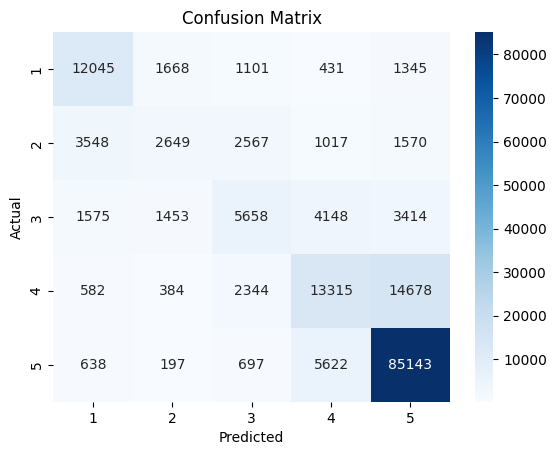

In [ ]:
# محاسبه ماتریکس درهم ریختگی
cm = confusion_matrix(y_val, y_pred)

# برچسب کلاس‌ها
labels = [1, 2, 3, 4, 5]

# رسم ماتریس
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()